# Lab 4: Digit darkness vs. two neural networks on MNIST

All techniques below are trained on the **exact same 50,000 training images** and scored on the same 10,000 test images.

In [1]:
import sys, os, random
sys.path.append(os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from nn import Network, load_data_wrapper

random.seed(470)
np.random.seed(470)

# load_data_wrapper returns zip iterators, so materialize them once and share them everywhere
train, val, test = load_data_wrapper(os.path.abspath('../../nn/mnist.pkl.gz'))
train, test = list(train), list(test)
print(len(train), 'training images,', len(test), 'test images')

50000 training images, 10000 test images


## Technique 1: digit darkness

For each digit 0-9, average the total darkness (sum of pixel values) of its training images. To classify a test image, pick the digit whose average darkness is closest to the image's darkness.

In [2]:
train_labels = np.array([np.argmax(y) for _, y in train])
train_dark = np.array([x.sum() for x, _ in train])
avg_dark = np.array([train_dark[train_labels == d].mean() for d in range(10)])
print('average darkness per digit:', np.round(avg_dark, 1))

def predict_darkness(x):
    return int(np.argmin(np.abs(avg_dark - x.sum())))

darkness_acc = np.mean([predict_darkness(x) == y for x, y in test])
print(f'digit darkness accuracy: {darkness_acc:.4f}')

average darkness per digit: [135.9  59.7 116.3 110.9  95.2 100.3 107.4  89.9 117.9  96. ]
digit darkness accuracy: 0.2225


## Bonus: regional darkness

Split each 28x28 image into a 4x4 grid of 7x7 regions and compute the darkness of each. For every digit, average the 16 region darknesses over the training images; a test image is assigned to the digit whose region-darkness profile is closest (smallest Euclidean distance).

In [3]:
def region_darkness(x, g=4):
    img = x.reshape(28, 28)
    s = 28 // g
    return img.reshape(g, s, g, s).sum(axis=(1, 3)).ravel()

train_regions = np.array([region_darkness(x) for x, _ in train])
profiles = np.array([train_regions[train_labels == d].mean(axis=0) for d in range(10)])

def predict_regions(x):
    return int(np.argmin(np.linalg.norm(profiles - region_darkness(x), axis=1)))

region_acc = np.mean([predict_regions(x) == y for x, y in test])
print(f'regional darkness accuracy: {region_acc:.4f}')

regional darkness accuracy: 0.6385


## Technique 2 & 3: two neural networks

Both networks use the same `train` list and are evaluated on the same `test` list after every epoch.

| | Network 1 (defaults) | Network 2 (tuned) |
|---|---|---|
| Layers | 784-30-10 | 784-50-10 |
| Learning rate (eta) | 3.0 | 6.0 |
| Mini-batch size | 10 | 10 |
| Epochs | 30 | 30 |

In [4]:
EPOCHS = 30

def train_tracking(net, train, test, epochs, batch_size, eta):
    """Mini-batch SGD that records test accuracy after every epoch."""
    data = list(train)
    accs = []
    for e in range(epochs):
        random.shuffle(data)
        for k in range(0, len(data), batch_size):
            net.update_mini_batch(data[k:k + batch_size], eta)
        accs.append(net.evaluate(test) / len(test))
        print(f'  epoch {e + 1:2d}: {accs[-1]:.4f}')
    return accs

print('Network 1: [784, 30, 10], eta=3.0, batch=10')
network1_accuracies = train_tracking(Network([784, 30, 10]), train, test, EPOCHS, batch_size=10, eta=3.0)

Network 1: [784, 30, 10], eta=3.0, batch=10
  epoch  1: 0.8274
  epoch  2: 0.8391
  epoch  3: 0.9255
  epoch  4: 0.9383
  epoch  5: 0.9413
  epoch  6: 0.9403
  epoch  7: 0.9461
  epoch  8: 0.9433


/Users/masonkimball/Documents/GitHub/cosc470_2026/nn/network.py:155: SyntaxWarning: invalid escape sequence '\p'
  """Return the vector of partial derivatives \partial C_x /


KeyboardInterrupt: 

In [ ]:
print('Network 2: [784, 50, 10], eta=6.0, batch=10')
network2_accuracies = train_tracking(Network([784, 50, 10]), train, test, EPOCHS, batch_size=10, eta=6.0)

Network 2: [784, 50, 10], eta=6.0, batch=10


  epoch  1: 0.8927


  epoch  2: 0.9309


  epoch  3: 0.9358


  epoch  4: 0.9451


...

  epoch 26: 0.9620


  epoch 27: 0.9619


  epoch 28: 0.9615


  epoch 29: 0.9626


  epoch 30: 0.9613


## Results

Hyperparameters: Network 1 uses the class defaults (30 hidden neurons, eta=3.0, batch size 10). Network 2 **changes** the hidden layer size (50) and learning rate (6.0), picked after short 4-epoch trials of a few settings (a lower eta of 1.0 with 100 hidden neurons stalled near 66%). Both train for 30 epochs on the same 50,000 images.

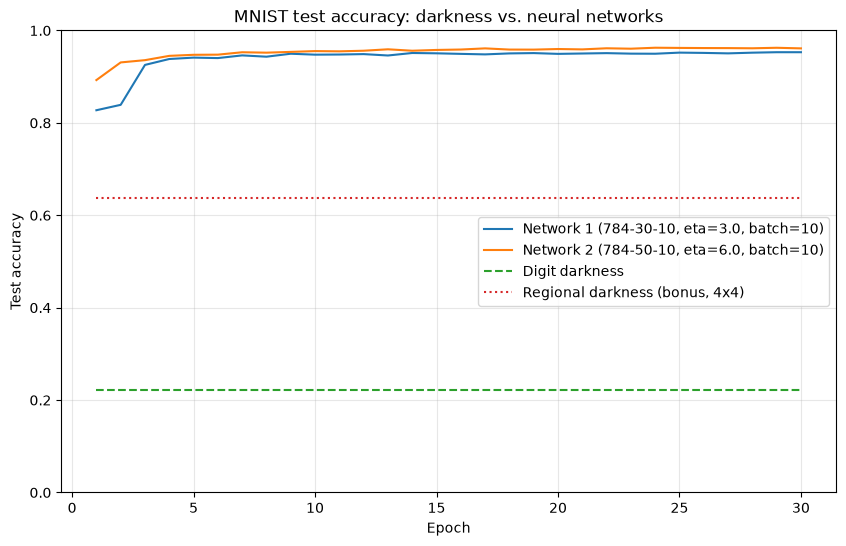

Digit darkness:      0.2225
Regional darkness:   0.6385
Network 1 (final):   0.9530  (best 0.9530)
Network 2 (final):   0.9613  (best 0.9627)


In [ ]:
darkness_accuracies = [darkness_acc] * EPOCHS
region_accuracies = [region_acc] * EPOCHS
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, network1_accuracies, label='Network 1 (784-30-10, eta=3.0, batch=10)')
plt.plot(epochs, network2_accuracies, label='Network 2 (784-50-10, eta=6.0, batch=10)')
plt.plot(epochs, darkness_accuracies, label='Digit darkness', linestyle='--')
plt.plot(epochs, region_accuracies, label='Regional darkness (bonus, 4x4)', linestyle=':')
plt.xlabel('Epoch')
plt.ylabel('Test accuracy')
plt.title('MNIST test accuracy: darkness vs. neural networks')
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend(loc='center right')
plt.show()

print(f'Digit darkness:      {darkness_acc:.4f}')
print(f'Regional darkness:   {region_acc:.4f}')
print(f'Network 1 (final):   {network1_accuracies[-1]:.4f}  (best {max(network1_accuracies):.4f})')
print(f'Network 2 (final):   {network2_accuracies[-1]:.4f}  (best {max(network2_accuracies):.4f})')